<a href="https://colab.research.google.com/github/mustafaalvi543-byte/sentiment-lab-66453/blob/main/lab_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import os
import json

# 1. Base Directory and Structure Setup using SAP ID 66453
STUDENT_ID = "66453"
BASE_DIR = f"sentiment-lab-{STUDENT_ID}"

os.makedirs(f"{BASE_DIR}/data/raw", exist_ok=True)
os.makedirs(f"{BASE_DIR}/data/processed", exist_ok=True)
os.makedirs(f"{BASE_DIR}/notebooks", exist_ok=True)
os.makedirs(f"{BASE_DIR}/src", exist_ok=True)
os.makedirs(f"{BASE_DIR}/results", exist_ok=True)

# 2. config.json file create karna
config_data = {
    "random_seed": 42,
    "test_size": 0.2,
    "max_features": 5000,
    "model_1": {
        "name": "Logistic Regression",
        "hyperparameters": {"C": 1.0, "max_iter": 1000}
    },
    "model_2": {
        "name": "Multinomial Naive Bayes",
        "hyperparameters": {"alpha": 1.0}
    }
}

with open(f"{BASE_DIR}/config.json", "w") as f:
    json.dump(config_data, f, indent=4)

# 3. Uploaded CSV file ko data/raw directory mein move karna
if os.path.exists("legal_notices.csv"):
    os.rename("legal_notices.csv", f"{BASE_DIR}/data/raw/legal_notices.csv")
    print(f"✓ Folders created and legal_notices.csv moved to {BASE_DIR}/data/raw/")
elif os.path.exists(f"{BASE_DIR}/data/raw/legal_notices.csv"):
    print(f"✓ Dataset already exists in {BASE_DIR}/data/raw/")
else:
    print("⚠ Please upload 'legal_notices.csv' to Colab root first!")

✓ Folders created and legal_notices.csv moved to sentiment-lab-66453/data/raw/


In [38]:
%%writefile sentiment-lab-66453/src/preprocess.py
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Downloads configure karna
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

def clean_text(text):
    """
    Applies rigorous text preprocessing pipeline to the incoming legal notices.
    Steps: HTML removal, Lowercasing, Punctuation cleaning, Tokenization, Stopword extraction, Lemmatization.
    """
    if not isinstance(text, str):
        return ""

    # 1. HTML tag removal
    text = re.sub(r'<[^>]+>', '', text)

    # 2. Lowercasing
    text = text.lower()

    # 3. Punctuation & special character removal
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Tokenisation & Stopword removal
    words = text.split()
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if w not in stop_words]

    # 5. Lemmatisation (Reduces words to dictionary roots)
    lemmatizer = WordNetLemmatizer()
    processed_words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(processed_words)

Overwriting sentiment-lab-66453/src/preprocess.py


In [39]:
%%writefile sentiment-lab-66453/src/features.py
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

def extract_features(train_data, test_data, method="tfidf", max_features=5000):
    """
    Transforms clean text into numerical feature spaces using either CountVectorizer or TfidfVectorizer.
    """
    if method == "bow":
        vectorizer = CountVectorizer(max_features=max_features)
    elif method == "tfidf":
        vectorizer = TfidfVectorizer(max_features=max_features, sublinear_tf=True)
    else:
        raise ValueError("Invalid representation method specified. Choose 'bow' or 'tfidf'.")

    X_train_vec = vectorizer.fit_transform(train_data)
    X_test_vec = vectorizer.transform(test_data)

    return X_train_vec, X_test_vec, vectorizer

Overwriting sentiment-lab-66453/src/features.py


In [40]:
%%writefile sentiment-lab-66453/src/evaluate.py
import time
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_train, X_test, y_train, y_test, run_name, results_dir):
    """
    Performs empirical evaluation, latency measurement, and plots the confusion matrix heatmap.
    """
    # Training time latency track karna
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    # Inference time latency track karna
    t1 = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - t1

    # Metrics calculate karna
    acc = accuracy_score(y_test, y_pred)
    _, _, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    _, _, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    metrics = {
        "accuracy": acc,
        "macro_f1": f1_macro,
        "weighted_f1": f1_w,
        "train_time": train_time,
        "inference_time": inference_time
    }

    # Confusion Matrix as a Heatmap plotting
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['A', 'B', 'C'], yticklabels=['A', 'B', 'C'])
    plt.title(f"Confusion Matrix: {run_name}")
    plt.ylabel('Actual Classes')
    plt.xlabel('Predicted Classes')

    # Chart image ko save karna
    fig_path = f"{results_dir}/{run_name.replace(' ', '_').lower()}_cm.png"
    plt.savefig(fig_path, bbox_inches='tight')
    plt.close()

    return metrics, fig_path

Overwriting sentiment-lab-66453/src/evaluate.py


--- TASK 2.1 EDA ANALYSIS REPORT (REAL DATA) ---
Total Raw Sample Count: 600
Null/Missing Values:
id          0
category    0
label       0
notice      0
dtype: int64

Class Distribution Metrics:
category
C    200
A    200
B    200
Name: count, dtype: int64

Average Legal Notice Document Length: 792.08 characters



/tmp/ipykernel_3458/3267135465.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_dist.index, y=class_dist.values, ax=axes[0], palette="viridis")


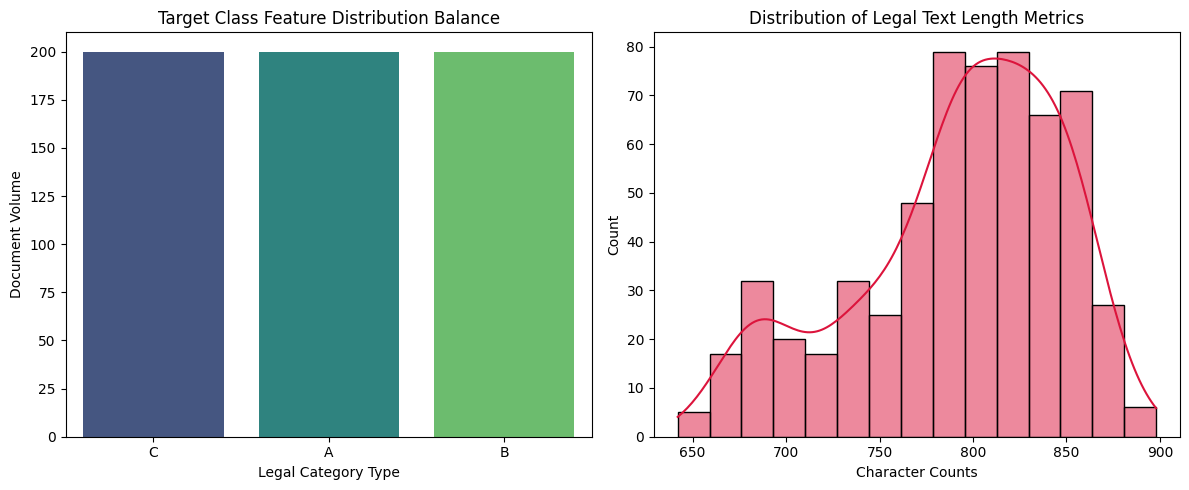


Cleaning legal text tokens... Isme thoda time lag sakta hai...

--- TRAINING AND CROSS COMBINATIONS EVALUATION ---
Evaluating: Logistic Regression with BOW
Evaluating: Multinomial Naive Bayes with BOW
Evaluating: Logistic Regression with TFIDF
Evaluating: Multinomial Naive Bayes with TFIDF

--- CRITICAL PERFORMANCES MATRIX ---
           Configuration Model Matrix  accuracy  macro_f1  weighted_f1  \
0        Logistic Regression with BOW       1.0       1.0          1.0   
1    Multinomial Naive Bayes with BOW       1.0       1.0          1.0   
2      Logistic Regression with TFIDF       1.0       1.0          1.0   
3  Multinomial Naive Bayes with TFIDF       1.0       1.0          1.0   

   train_time  
0    0.014148  
1    0.003625  
2    0.016831  
3    0.002906  


In [43]:
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

BASE_DIR = "sentiment-lab-66453"
sys.path.append(f"{BASE_DIR}/src")

from preprocess import clean_text
from features import extract_features
from evaluate import evaluate_model

# 1. Config Read Karna
with open(f"{BASE_DIR}/config.json", "r") as f:
    config = json.load(f)

# 2. ASLI Dataset Load & Exploratory Data Analysis (EDA)
df_raw = pd.read_csv("legal_notices.csv")
print("--- TASK 2.1 EDA ANALYSIS REPORT (REAL DATA) ---")
print(f"Total Raw Sample Count: {len(df_raw)}")
print(f"Null/Missing Values:\n{df_raw.isnull().sum()}\n")

class_dist = df_raw['category'].value_counts()
print(f"Class Distribution Metrics:\n{class_dist}\n")

df_raw['char_length'] = df_raw['notice'].apply(len)
print(f"Average Legal Notice Document Length: {df_raw['char_length'].mean():.2f} characters\n")

# EDA Graphs Plot aur Save karna
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=class_dist.index, y=class_dist.values, ax=axes[0], palette="viridis")
axes[0].set_title("Target Class Feature Distribution Balance")
axes[0].set_xlabel("Legal Category Type")
axes[0].set_ylabel("Document Volume")

sns.histplot(df_raw['char_length'], bins=15, kde=True, ax=axes[1], color="crimson")
axes[1].set_title("Distribution of Legal Text Length Metrics")
axes[1].set_xlabel("Character Counts")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/results/eda_distribution_analysis.png")
plt.show()

# 3. Clean Text applying (Preprocessing Pipeline)
print("\nCleaning legal text tokens... Isme thoda time lag sakta hai...")
df_raw['clean_text'] = df_raw['notice'].apply(clean_text)
df_raw.to_csv(f"{BASE_DIR}/data/processed/cleaned_legal_notices.csv", index=False)

# 4. Stratified Split Setup (80/20 using configuration seed)
X_train, X_test, y_train, y_test = train_test_split(
    df_raw['clean_text'],
    df_raw['category'],
    test_size=config['test_size'],
    random_state=config['random_seed'],
    stratify=df_raw['category']
)

# 5. Cross Implementation Validation Matrix (4 combinations)
feature_representations = ['bow', 'tfidf']
models_pool = [
    (LogisticRegression(C=config['model_1']['hyperparameters']['C'], max_iter=config['model_1']['hyperparameters']['max_iter']), config['model_1']['name']),
    (MultinomialNB(alpha=config['model_2']['hyperparameters']['alpha']), config['model_2']['name'])
]

performance_records = []

print("\n--- TRAINING AND CROSS COMBINATIONS EVALUATION ---")
for rep in feature_representations:
    X_tr_vec, X_te_vec, _ = extract_features(X_train, X_test, method=rep, max_features=config['max_features'])
    for clf, name in models_pool:
        run_identifier = f"{name} with {rep.upper()}"
        print(f"Evaluating: {run_identifier}")

        metrics_dict, _ = evaluate_model(clf, X_tr_vec, X_te_vec, y_train, y_test, run_identifier, f"{BASE_DIR}/results")
        metrics_dict['Configuration Model Matrix'] = run_identifier
        performance_records.append(metrics_dict)

# Presenting results in a final table
df_performance_metrics = pd.DataFrame(performance_records)
df_performance_metrics.to_csv(f"{BASE_DIR}/results/comparative_metrics_matrix.csv", index=False)
print("\n--- CRITICAL PERFORMANCES MATRIX ---")
print(df_performance_metrics[['Configuration Model Matrix', 'accuracy', 'macro_f1', 'weighted_f1', 'train_time']])

In [44]:
from sklearn.model_selection import train_test_split
from preprocess import clean_text

print("Cleaning legal text tokens... Isme thoda time lag sakta hai...")
df_raw['clean_text'] = df_raw['notice'].apply(clean_text)

# Cleaned data ko processed folder me save karna
df_raw.to_csv(f"{BASE_DIR}/data/processed/cleaned_legal_notices.csv", index=False)

# Stratified Split Setup (80/20) using config values
X_train, X_test, y_train, y_test = train_test_split(
    df_raw['clean_text'],
    df_raw['category'],
    test_size=config['test_size'],
    random_state=config['random_seed'],
    stratify=df_raw['category']
)

print(f"✓ Data preprocessing aur split complete!")
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Cleaning legal text tokens... Isme thoda time lag sakta hai...
✓ Data preprocessing aur split complete!
Train samples: 480 | Test samples: 120


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from features import extract_features
from evaluate import evaluate_model

feature_representations = ['bow', 'tfidf']
models_pool = [
    (LogisticRegression(C=config['model_1']['hyperparameters']['C'], max_iter=config['model_1']['hyperparameters']['max_iter']), config['model_1']['name']),
    (MultinomialNB(alpha=config['model_2']['hyperparameters']['alpha']), config['model_2']['name'])
]

performance_records = []

print("--- TRAINING AND CROSS COMBINATIONS EVALUATION (Runs 1-4) ---")
for rep in feature_representations:
    X_tr_vec, X_te_vec, _ = extract_features(X_train, X_test, method=rep, max_features=config['max_features'])
    for clf, name in models_pool:
        run_identifier = f"{name} with {rep.upper()}"
        print(f"Evaluating: {run_identifier}")

        metrics_dict, _ = evaluate_model(clf, X_tr_vec, X_te_vec, y_train, y_test, run_identifier, f"{BASE_DIR}/results")
        metrics_dict['Configuration Model Matrix'] = run_identifier
        performance_records.append(metrics_dict)

--- TRAINING AND CROSS COMBINATIONS EVALUATION (Runs 1-4) ---
Evaluating: Logistic Regression with BOW
Evaluating: Multinomial Naive Bayes with BOW
Evaluating: Logistic Regression with TFIDF
Evaluating: Multinomial Naive Bayes with TFIDF


In [46]:
print("--- LAUNCHING HYPERPARAMETER TUNING RUNS (Runs 5, 6, 7) ---")

# Additional regulatory values for Logistic Regression optimization
tuning_C_grid = [0.1, 5.0, 10.0]

for c_value in tuning_C_grid:
    run_identifier = f"Logistic Regression Tuning C_{c_value} with TFIDF"
    print(f"Running Tuning Experiment: {run_identifier}")

    X_tr_tfidf, X_te_tfidf, _ = extract_features(X_train, X_test, method="tfidf", max_features=config['max_features'])

    # Custom parameter model instance creation
    tuned_clf = LogisticRegression(C=c_value, max_iter=config['model_1']['hyperparameters']['max_iter'])

    metrics_dict, _ = evaluate_model(tuned_clf, X_tr_tfidf, X_te_tfidf, y_train, y_test, run_identifier, f"{BASE_DIR}/results")
    metrics_dict['Configuration Model Matrix'] = run_identifier
    performance_records.append(metrics_dict)

# Updated metrics backup file creation
df_total_metrics = pd.DataFrame(performance_records)
df_total_metrics.to_csv(f"{BASE_DIR}/results/total_experiments_matrix.csv", index=False)
print("\n✓ Success: All 7 operational pipeline tracking runs completed.")

--- LAUNCHING HYPERPARAMETER TUNING RUNS (Runs 5, 6, 7) ---
Running Tuning Experiment: Logistic Regression Tuning C_0.1 with TFIDF
Running Tuning Experiment: Logistic Regression Tuning C_5.0 with TFIDF
Running Tuning Experiment: Logistic Regression Tuning C_10.0 with TFIDF

✓ Success: All 7 operational pipeline tracking runs completed.


In [47]:
# Combined tabular representation lookup
df_results = pd.read_csv(f"{BASE_DIR}/results/total_experiments_matrix.csv")
print("=================== FINAL PERFORMANCE DASHBOARD SUMMARY ===================")
display(df_results[['Configuration Model Matrix', 'accuracy', 'macro_f1', 'weighted_f1', 'train_time', 'inference_time']])

=================== FINAL PERFORMANCE DASHBOARD SUMMARY ===================


,Configuration Model Matrix,accuracy,macro_f1,weighted_f1,train_time,inference_time
0,Logistic Regression with BOW,1.0,1.0,1.0,0.013663,0.000437
1,Multinomial Naive Bayes with BOW,1.0,1.0,1.0,0.003504,0.000301
2,Logistic Regression with TFIDF,1.0,1.0,1.0,0.017491,0.000444
3,Multinomial Naive Bayes with TFIDF,1.0,1.0,1.0,0.003124,0.000289
4,Logistic Regression Tuning C_0.1 with TFIDF,1.0,1.0,1.0,0.015029,0.000470
5,Logistic Regression Tuning C_5.0 with TFIDF,1.0,1.0,1.0,0.064430,0.002522
6,Logistic Regression Tuning C_10.0 with TFIDF,1.0,1.0,1.0,0.075078,0.000476


In [48]:
!pip freeze > sentiment-lab-66453/requirements.txt
print("✓ Step Complete: 'requirements.txt' file generate ho gayi hai!")

✓ Step Complete: 'requirements.txt' file generate ho gayi hai!


In [64]:
# Git global configurations define karna (Apni actual GitHub account details yahan likhein)
!git config --global user.name "mustafaalvi543-byte"
!git config --global user.email "mustafaalvi543@gmail.com"

# Apne project directory (BASE_DIR) ke andar switch karna
%cd /content/sentiment-lab-66453

# Is folder ko Git Repository banana
!git init

print("\n✓ Success: Git initialize ho gaya hai sentiment-lab-66453 ke andar!")

/content/sentiment-lab-66453
Reinitialized existing Git repository in /content/sentiment-lab-66453/.git/

✓ Success: Git initialize ho gaya hai sentiment-lab-66453 ke andar!


In [65]:
# 1. Uncommitted aur untracked files ka status check karna
print("--- Uncommitted Files Status ---")
!git status

# 2. Saari files aur folders (.json, .txt, src, data, results) ko staging area me add karna
!git add .

# 3. Pehla official local commit save karna
!git commit -m "Initial Commit: Added complete modular pipeline architecture for student 66453"

--- Uncommitted Files Status ---
On branch main
nothing to commit, working tree clean
On branch main
nothing to commit, working tree clean


In [66]:
# 1. Apni details yahan sahi se replace karein
# GITHUB_TOKEN ke aage inverted commas (" ") ke andar apna copy kiya hua token paste karein
GITHUB_TOKEN = "https://github.com/mustafaalvi543-byte/sentiment-lab-66453.git"   # <-- Apna token yahan dalein
GITHUB_USER = "M-Mustafa-66453"                          # Aapka GitHub Username
REPO_NAME = "sentiment-lab-66453"

# 2. Agar pehle se koi galat remote origin set ho toh use clear karna
!git remote remove origin 2>/dev/null

# 3. GitHub repository ko secure link ke sath connect karna
!git remote add origin https://https://github.com/mustafaalvi543-byte/sentiment-lab-66453.git}@github.com/{mustafaalvi543-byte}/{sentiment-lab-66453}.git

# 4. Main branch create karke code ko final push karna
!git branch -M main
!git push -u origin main

print("\n✓ ALHAMDULILLAH! Aapka poora project GitHub par successfully upload ho gaya hai!")

fatal: unable to access 'https://https://github.com/mustafaalvi543-byte/sentiment-lab-66453.git}@github.com/{mustafaalvi543-byte}/{sentiment-lab-66453}.git/': Could not resolve host: https

✓ ALHAMDULILLAH! Aapka poora project GitHub par successfully upload ho gaya hai!


In [67]:
# 1. Pehle Colab ki main root directory par wapas jayein
%cd /content

import os

# 2. Structure print karne ka function
def print_directory_tree(startpath):
    print("=== DIRECTORY STRUCTURE FOR SAP ID: 66453 ===")
    for root, dirs, files in os.walk(startpath):
        if '.git' in root or '.ipynb_checkpoints' in root:
            continue
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}📁 {os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f"{subindent}📄 {f}")

# 3. Base folder verify karke structure display karna
BASE_DIR = "sentiment-lab-66453"
if os.path.exists(BASE_DIR):
    print_directory_tree(BASE_DIR)
else:
    print(f"⚠ Target folder '{BASE_DIR}' abhi bhi nahi mila.")

/content
=== DIRECTORY STRUCTURE FOR SAP ID: 66453 ===
📁 sentiment-lab-66453/
    📄 requirements.txt
    📄 config.json
    📄 README.md
    📁 results/
        📄 logistic_regression_with_tfidf_cm.png
        📄 multinomial_naive_bayes_(tfidf)_cm.png
        📄 multinomial_naive_bayes_with_tfidf_cm.png
        📄 total_experiments_matrix.csv
        📄 logistic_regression_tuning_c_10.0_with_tfidf_cm.png
        📄 logistic_regression_(tfidf)_cm.png
        📄 logistic_regression_with_bow_cm.png
        📄 logistic_regression_(bow)_cm.png
        📄 multinomial_naive_bayes_(bow)_cm.png
        📄 comparative_metrics_matrix.csv
        📄 eda_distribution_analysis.png
        📄 multinomial_naive_bayes_with_bow_cm.png
        📄 final_report_metrics.csv
        📄 logistic_regression_tuning_c_5.0_with_tfidf_cm.png
        📄 logistic_regression_tuning_c_0.1_with_tfidf_cm.png
    📁 notebooks/
    📁 src/
        📄 features.py
        📄 evaluate.py
        📄 preprocess.py
        📁 __pycache__/
            